## Predicting Unknown Data


In [1]:
import pickle
import joblib

from shelterbelts.classifications.predictions import tif_prediction_ds, _load_keras_model
from shelterbelts.utils.filepaths import sentinel_sample, get_pretrained_nn, get_pretrained_scaler

In [2]:
# Load some example sentinel imagery
with open(sentinel_sample, 'rb') as f:
    ds = pickle.load(f)

ds

<xarray.Dataset> Size: 337kB
Dimensions:           (time: 33, y: 15, x: 17)
Coordinates:
  * time              (time) datetime64[ns] 264B 2020-01-10T00:06:22.308020 ....
  * y                 (y) float64 120B -4.205e+06 -4.205e+06 ... -4.205e+06
  * x                 (x) float64 136B 1.661e+07 1.661e+07 ... 1.661e+07
    spatial_ref       int32 4B 3857
Data variables:
    nbart_blue        (time, y, x) float32 34kB 1.008e+03 1.008e+03 ... 403.0
    nbart_green       (time, y, x) float32 34kB 1.355e+03 1.355e+03 ... 648.0
    nbart_red         (time, y, x) float32 34kB 1.942e+03 1.942e+03 ... 717.0
    nbart_red_edge_1  (time, y, x) float32 34kB 2.132e+03 ... 1.141e+03
    nbart_red_edge_2  (time, y, x) float32 34kB 2.253e+03 ... 1.815e+03
    nbart_red_edge_3  (time, y, x) float32 34kB 2.59e+03 2.59e+03 ... 2.11e+03
    nbart_nir_1       (time, y, x) float32 34kB 2.886e+03 ... 2.487e+03
    nbart_nir_2       (time, y, x) float32 34kB 2.912e+03 ... 2.505e+03
    nbart_swir_2      (time, y, x) float32 34kB 3.831e+03 ... 2.132e+03
    nbart_swir_3      (time, y, x) float32 34kB 2.883e+03 ... 1.224e+03
Attributes:
    crs:           EPSG:3857
    grid_mapping:  spatial_ref

In [3]:
# Load the pre-trained model
model = _load_keras_model(get_pretrained_nn())
scaler = joblib.load(get_pretrained_scaler())

/g/data/xe2/cb8590/miniconda/envs/shelterbelts/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## 1. Binary tree classification

Saved: ./prediction_predicted.tif
CPU times: user 513 ms, sys: 127 ms, total: 640 ms
Wall time: 1.41 s


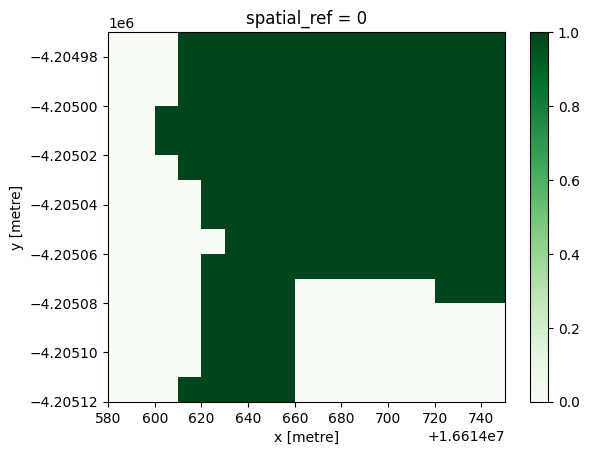

In [4]:
%%time
da = tif_prediction_ds(ds, model=model, scaler=scaler)
da.plot(cmap='Greens')

## 2. Tree likelihood predictions (% confidence)

Saved: ./prediction_predicted.tif
CPU times: user 527 ms, sys: 9.84 ms, total: 537 ms
Wall time: 541 ms


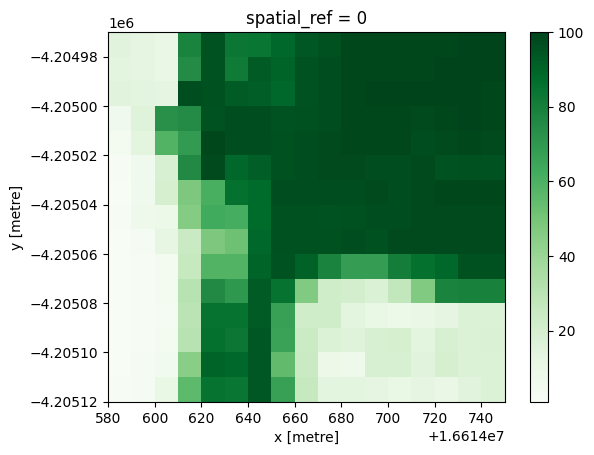

In [5]:
%%time
da_conf = tif_prediction_ds(ds, model=model, scaler=scaler, confidence=True)
da_conf.plot(cmap='Greens')

## 3. Weighted average of multiple models (1 per koppen region)


/g/data/xe2/cb8590/miniconda/envs/shelterbelts/lib/python3.11/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Model weights: [('Cfb', 100)]
Saved: outdir/demo_multi_predicted.tif
CPU times: user 1.11 s, sys: 1.1 s, total: 2.21 s
Wall time: 5.48 s


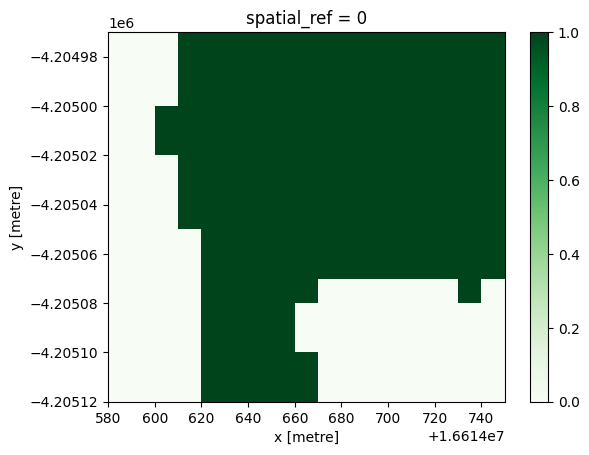

In [6]:
%%time
da_multi = tif_prediction_ds(ds, outdir='outdir', stub='demo_multi', weighted_average=True)
da_multi.plot(cmap='Greens')